# Fraud Detection Logistic Regression with FDUS Undersampling

Train a tuned logistic regression model for fraud detection using FDUS (Fitting Data Distribution with UnderSampling) at a 1:5 ratio inside stratified group k-fold cross-validation. These were the best results from cluster based undersampling.

Reference: Zhou, W., Liu, C., Yuan, P., & Jiang, L. (2024). "An Undersampling Method Approaching the Ideal Classification Boundary for Imbalance Problems." Applied Sciences, 14(13), 5421.

Use one logistic regression model only; apply FDUS undersampling inside each CV fold to avoid data leakage; tune hyperparameters with PR-AUC as the primary metric; and produce NPI-level fraud risk probabilities.

## Steps
- Load and explore the fraud dataset with extreme class imbalance
- Define the FDUS undersampler from Zhou et al. (2024)
- Build a preprocessing + logistic regression pipeline
- Run stratified group k-fold CV with FDUS applied per fold
- Tune logistic regression hyperparameters via grid search with PR-AUC
- Generate precision-recall curves and select a decision threshold
- Analyze feature importance from the final model
- Output NPI-level fraud risk probabilities
- Save the best model and results

# Imports and Configuration

In [10]:
# Track model training time
from time import time

# Handle arrays and tables
import numpy as np
import pandas as pd

# Build plots
import matplotlib.pyplot as plt
import seaborn as sns

# Build preprocessing pipelines
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split data and tune the model
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold
from sklearn.cluster import MiniBatchKMeans

# Train the classifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Measure model performance
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

# Save trained artifacts
import joblib

ImportError: cannot import name 'StratifiedGroupKFold' from 'sklearn.model_selection' (/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/__init__.py)

# Load the Dataset
Load the fraud dataset and examine its basic properties.

In [4]:
# Load the dataset
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/unified_dataset.csv")

# Display basic information
print("Total dataset size")
print(f"n_samples: {df.shape[0]:,}")
print(f"n_features: {df.shape[1] - 1}")

# Display first few rows
print("\nFirst few rows:")
print(df.head())

# Check columns
print("\nColumn names:")
print(df.columns.tolist())

Total dataset size
n_samples: 140,827
n_features: 215

First few rows:
          npi rfrg_prvdr_state_abrvtn  year  target  \
0  1003000597                      OK  2022       0   
1  1003000597                      OK  2023       0   
2  1003000902                      KY  2021       0   
3  1003000902                      KY  2022       0   
4  1003000902                      KY  2023       0   

   avg_suplr_mdcr_pymt_amt_sum  \
0                     1.692306   
1                    23.833223   
2                   155.711788   
3                    67.361088   
4                    40.802223   

   tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum  \
0                                           0.166923   
1                                          -0.150274   
2                                          -2.380244   
3                                          -2.190131   
4                                          -1.466342   

   tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median 

# Initialize Training Configuration
Create the core settings and helper functions used throughout the notebook.

In [5]:
# Define key column names
target_col = 'target'
npi_col = 'npi'

# Define the primary tuning metric
primary_metric = 'average_precision'

# Random state for reproducibility
random_state = 42

# FDUS configuration
fdus_ratio = 5.0
fdus_alpha = 0.5
fdus_n_clusters = 30

# Cross-validation folds
n_cv_folds = 5

# Columns to exclude from features
exclude_cols = [
    'npi', 'rfrg_prvdr_state_abrvtn', 'year', 'target',
    'og_specialty_name', 'first_payment_date', 'last_payment_date',
    'specialty_type', 'specialty'
]

# Create a helper to calculate classification metrics
def evaluate_predictions(y_true, y_pred, y_pred_proba):
    # Build a dictionary of core evaluation metrics
    metrics = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_pred_proba),
        'roc_auc': np.nan
    }

    # Calculate ROC-AUC only when both classes are present
    if pd.Series(y_true).nunique() > 1:
        metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)

    # Return the metrics dictionary
    return metrics

# Create a helper to find the best classification threshold
def find_best_threshold(y_true, y_pred_proba):
    # Generate the precision-recall curve points
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_pred_proba)

    # Return a default threshold if no thresholds are available
    if len(thresholds) == 0:
        return 0.50, pd.DataFrame({'threshold': [0.50], 'precision': [precision_vals[-1]],
                                    'recall': [recall_vals[-1]], 'f1_score': [0.0]})

    # Align precision and recall with the threshold array
    aligned_precision = precision_vals[:-1]
    aligned_recall = recall_vals[:-1]

    # Calculate the F1 score at each threshold
    f1_scores = (2 * aligned_precision * aligned_recall) / np.clip(
        aligned_precision + aligned_recall, 1e-12, None)

    # Build a threshold summary table
    threshold_results = pd.DataFrame({
        'threshold': thresholds,
        'precision': aligned_precision,
        'recall': aligned_recall,
        'f1_score': f1_scores
    }).sort_values('f1_score', ascending=False).reset_index(drop=True)

    # Select the threshold with the best validation F1 score
    best_threshold = float(threshold_results.loc[0, 'threshold'])

    return best_threshold, threshold_results

print("Configuration initialized")
print(f"  FDUS ratio: 1:{int(fdus_ratio)}")
print(f"  FDUS alpha: {fdus_alpha}")
print(f"  CV folds: {n_cv_folds}")
print(f"  Primary metric: {primary_metric}")

Configuration initialized
  FDUS ratio: 1:5
  FDUS alpha: 0.5
  CV folds: 5
  Primary metric: average_precision


# FDUS Implementation
Define the FDUS undersampler based on Zhou et al. (2024). The algorithm:
1. Fits a separating hyperplane using logistic regression
2. Clusters the majority class with K-Means
3. Applies spatial compression to focus on boundary regions
4. Uses weighted sampling where points closer to the decision boundary have higher selection probability

In [6]:
class FDUSUndersampler:
    """
    FDUS: Fitting Data Distribution with UnderSampling

    Based on Zhou et al. (2024). kNN noise filtering removed - ineffective
    at extreme imbalance ratios (2600:1) where it removes 0 samples.
    """

    def __init__(self, n_clusters=30, alpha=0.5, target_ratio=5.0, random_state=42):
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.target_ratio = target_ratio
        self.random_state = random_state
        self.hyperplane_ = None
        self.cluster_model_ = None
        self.cluster_labels_ = None

    def _get_optimal_hyperplane(self, X, y):
        """Find separating hyperplane using logistic regression"""
        clf = LogisticRegression(max_iter=500, random_state=self.random_state,
                                  solver='saga', n_jobs=-1)
        clf.fit(X, y)
        return clf

    def _compute_distance_to_hyperplane(self, X, clf):
        """Compute perpendicular distance from each point to hyperplane"""
        w = clf.coef_.flatten()
        b = clf.intercept_[0] if hasattr(clf.intercept_, '__len__') else clf.intercept_
        distances = np.abs(np.dot(X, w) + b) / np.linalg.norm(w)
        return distances

    def _weighted_cluster_undersample(self, X_majority, distances, n_samples_target):
        """Weighted Undersampling based on Clustering (WUC) - Algorithm 1 from paper"""
        np.random.seed(self.random_state)

        self.cluster_model_ = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            batch_size=1024,
            n_init=3
        )
        self.cluster_labels_ = self.cluster_model_.fit_predict(X_majority)

        samples_per_cluster = max(1, n_samples_target // self.n_clusters)

        selected_indices = []

        for cluster_id in range(self.n_clusters):
            cluster_mask = self.cluster_labels_ == cluster_id
            cluster_indices = np.where(cluster_mask)[0]

            if len(cluster_indices) == 0:
                continue

            cluster_distances = distances[cluster_indices]

            # L_i,f(x) = L_max - L_min (diameter facing hyperplane)
            L_max = cluster_distances.max()
            L_min = cluster_distances.min()
            L_diameter = L_max - L_min

            # Spatial compression: only sample from boundary region
            COMPRESSION_THRESHOLD = L_min + self.alpha * L_diameter
            boundary_mask = cluster_distances <= COMPRESSION_THRESHOLD
            boundary_indices = cluster_indices[boundary_mask]

            if len(boundary_indices) == 0:
                boundary_indices = cluster_indices

            boundary_distances = distances[boundary_indices]

            # Weighted sampling: closer to boundary = higher weight
            eps = 1e-10
            weights = 1.0 / (boundary_distances + eps)
            weights = weights * np.random.random(len(weights))
            weights = weights / weights.sum()

            n_to_sample = min(samples_per_cluster, len(boundary_indices))

            if n_to_sample > 0:
                sampled = np.random.choice(
                    boundary_indices,
                    size=n_to_sample,
                    replace=False,
                    p=weights
                )
                selected_indices.extend(sampled)

        return np.array(selected_indices)

    def fit_resample(self, X_majority, X_minority, verbose=True):
        """Apply FDUS undersampling"""
        n_minority = len(X_minority)
        n_majority = len(X_majority)

        # Combine for hyperplane fitting
        X_combined = np.vstack([X_majority, X_minority])
        y_combined = np.concatenate([np.zeros(n_majority), np.ones(n_minority)])

        # Step 1: Fit hyperplane
        if verbose:
            print(f"    FDUS: Fitting hyperplane...", end=" ", flush=True)
        self.hyperplane_ = self._get_optimal_hyperplane(X_combined, y_combined)
        if verbose:
            print("done")

        # Step 2: Compute distances
        distances = self._compute_distance_to_hyperplane(X_majority, self.hyperplane_)

        # Step 3: Weighted cluster sampling
        n_target = int(n_minority * self.target_ratio)
        if verbose:
            print(f"    FDUS: Weighted cluster sampling (target: {n_target})...", end=" ", flush=True)
        selected_idx = self._weighted_cluster_undersample(X_majority, distances, n_target)
        if verbose:
            print("done")

        # Build final dataset
        X_resampled = np.vstack([X_minority, X_majority[selected_idx]])
        y_resampled = np.concatenate([np.ones(n_minority), np.zeros(len(selected_idx))])

        # Shuffle
        shuffle_idx = np.random.permutation(len(y_resampled))
        X_resampled = X_resampled[shuffle_idx]
        y_resampled = y_resampled[shuffle_idx]

        if verbose:
            print(f"    FDUS: {len(X_resampled):,} samples "
                  f"({(y_resampled == 0).sum():,} maj / {(y_resampled == 1).sum()} min)")

        return X_resampled, y_resampled

print("FDUS class defined")

FDUS class defined


# Examine Class Imbalance
Check the distribution of fraud vs. non-fraud cases.

Class Distribution:
0    140771
1        56
Name: target, dtype: int64

Majority:Minority ratio: 2,514:1
Minority class percentage: 0.0398%

Total unique NPIs: 63,117
NPIs with fraud: 23
NPIs without fraud: 63,094


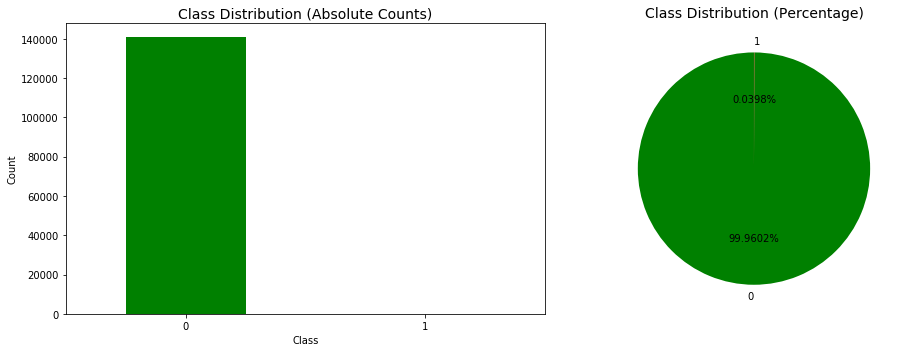

In [7]:
# Check class distribution
class_counts = df[target_col].value_counts().sort_index()
majority_count = int(class_counts.max())
minority_count = int(class_counts.min())
imbalance_ratio = majority_count / max(minority_count, 1)

print("Class Distribution:")
print(class_counts)
print(f"\nMajority:Minority ratio: {imbalance_ratio:,.0f}:1")
print(f"Minority class percentage: {minority_count / len(df) * 100:.4f}%")

# NPI-level fraud summary
npi_fraud = df.groupby(npi_col)[target_col].max()
print(f"\nTotal unique NPIs: {len(npi_fraud):,}")
print(f"NPIs with fraud: {npi_fraud.sum()}")
print(f"NPIs without fraud: {(npi_fraud == 0).sum():,}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution (Absolute Counts)', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(class_counts.index.astype(str), rotation=0)

axes[1].pie(class_counts, labels=class_counts.index.astype(str),
            autopct='%1.4f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=14)

plt.tight_layout()
plt.show()

# Data Preprocessing
Identify feature types, check data quality, and prepare the feature set.

In [8]:
# Identify feature columns (numeric only, excluding metadata)
exclude_cols_set = list(dict.fromkeys(exclude_cols))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols_set]

print(f"Number of features kept: {len(feature_cols)}")

# Check for missing values
missing = df[feature_cols].isnull().sum()
if missing.sum() > 0:
    print(f"\nColumns with missing values: {(missing > 0).sum()}")
    print(missing[missing > 0])
else:
    print("No missing values found in feature columns")

# Clean the dataset
df_clean = df[feature_cols + [target_col, npi_col]].dropna().reset_index(drop=True)
print(f"\nSamples after dropping NaN: {len(df_clean):,}")

# Separate features, target, and groups
X = df_clean[feature_cols].values
y = df_clean[target_col].values
groups = df_clean[npi_col].values

print(f"\nClass Distribution:")
print(f"  Non-Fraud (0): {(y == 0).sum():,}")
print(f"  Fraud (1): {(y == 1).sum()}")

# Display basic statistics
print("\nBasic statistics for features:")
print(df_clean[feature_cols].describe())

Number of features kept: 175
No missing values found in feature columns

Samples after dropping NaN: 140,827

Class Distribution:
  Non-Fraud (0): 140,771
  Fraud (1): 56

Basic statistics for features:
       avg_suplr_mdcr_pymt_amt_sum  \
count                140827.000000   
mean                    338.383343   
std                     737.240101   
min                       0.000000   
25%                      50.080000   
50%                     137.543136   
75%                     363.802523   
max                   94737.962397   

       tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum  \
count                                      140827.000000   
mean                                            0.079440   
std                                             6.868918   
min                                           -11.243037   
25%                                            -1.422018   
50%                                            -0.689416   
75%                               

# Stratified Group K-Fold CV with FDUS + Grid Search
Run FDUS undersampling inside each CV fold to avoid leaking boundary information across folds. Tune logistic regression hyperparameters with PR-AUC as the gold metric.

Each fold:
1. Scale features using only the training fold
2. Apply FDUS 1:5 undersampling on the training fold majority class
3. Run grid search for logistic regression hyperparameters
4. Evaluate on the held-out fold at the original imbalanced distribution

In [9]:
######################################################################
# STRATIFIED GROUP K-FOLD CV WITH FDUS UNDERSAMPLING + GRID SEARCH
########################################################################

# Define the outer CV strategy grouped by NPI
outer_cv = StratifiedGroupKFold(n_splits=n_cv_folds, shuffle=True, random_state=random_state)

# Define the logistic regression parameter grid
param_grid = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
    },
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'l1_ratio': [0.25, 0.5, 0.75],
        'class_weight': ['balanced']
    }
]

# Storage for fold results
fold_metrics = []
fold_best_params = []
fold_probas = []  # Store (indices, probabilities) for NPI-level output
fold_models = []
all_test_indices = []
all_test_probas = []
all_test_labels = []

start_time = time()

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{n_cv_folds}")
    print(f"{'='*60}")

    # Split data
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]
    groups_train_fold = groups[train_idx]

    print(f"  Train: {len(X_train_fold):,} samples "
          f"({(y_train_fold == 1).sum()} fraud, {(y_train_fold == 0).sum():,} non-fraud)")
    print(f"  Test:  {len(X_test_fold):,} samples "
          f"({(y_test_fold == 1).sum()} fraud, {(y_test_fold == 0).sum():,} non-fraud)")

    # Skip fold if no fraud in test
    if y_test_fold.sum() == 0:
        print("  WARNING: No fraud in test fold, skipping")
        continue

    # Step 1: Scale features using training fold only
    step_start = time()
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)
    print(f"  [Step 1/4] Scaling features... done ({time() - step_start:.1f}s)")

    # Step 2: Apply FDUS undersampling on training fold
    majority_idx = np.where(y_train_fold == 0)[0]
    minority_idx = np.where(y_train_fold == 1)[0]

    fdus = FDUSUndersampler(
        n_clusters=fdus_n_clusters,
        alpha=fdus_alpha,
        target_ratio=fdus_ratio,
        random_state=random_state
    )

    step_start = time()
    X_train_resampled, y_train_resampled = fdus.fit_resample(
        X_train_scaled[majority_idx],
        X_train_scaled[minority_idx]
    )
    print(f"  [Step 2/4] FDUS undersampling... done ({time() - step_start:.1f}s)")

    # Step 3: Inner grid search on the FDUS-undersampled training data
    inner_cv = StratifiedKFold(n_splits=min(3, int(y_train_resampled.sum())),
                                shuffle=True, random_state=random_state)

    grid_search = GridSearchCV(
        estimator=LogisticRegression(max_iter=2000, random_state=random_state),
        param_grid=param_grid,
        scoring=primary_metric,
        cv=inner_cv,
        n_jobs=-1,
        verbose=0
    )

    step_start = time()
    grid_search.fit(X_train_resampled, y_train_resampled)
    print(f"  [Step 3/4] Grid search... done ({time() - step_start:.1f}s)")

    best_lr = grid_search.best_estimator_
    fold_best_params.append(grid_search.best_params_)
    fold_models.append((scaler, best_lr))

    print(f"  Best inner CV PR-AUC: {grid_search.best_score_:.4f}")
    print(f"  Best params: {grid_search.best_params_}")

    # Step 4: Evaluate on the held-out test fold (original imbalanced distribution)
    step_start = time()
    y_test_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

    # Store predictions for NPI-level output
    all_test_indices.extend(test_idx.tolist())
    all_test_probas.extend(y_test_proba.tolist())
    all_test_labels.extend(y_test_fold.tolist())

    # Calculate fold metrics
    fold_auc_roc = roc_auc_score(y_test_fold, y_test_proba)
    fold_auc_pr = average_precision_score(y_test_fold, y_test_proba)

    fold_metrics.append({
        'fold': fold_idx + 1,
        'auc_roc': fold_auc_roc,
        'auc_pr': fold_auc_pr,
        'train_fraud': int(y_train_fold.sum()),
        'test_fraud': int(y_test_fold.sum()),
        'train_resampled': len(y_train_resampled)
    })

    print(f"  [Step 4/4] Evaluation... done ({time() - step_start:.1f}s)")
    print(f"  Fold AUC-ROC: {fold_auc_roc:.4f}")
    print(f"  Fold AUC-PR:  {fold_auc_pr:.4f}")

elapsed_time = time() - start_time

# Display CV summary
print(f"CROSS-VALIDATION SUMMARY ({elapsed_time:.1f}s)")
print(f"{'-'*80}")

cv_results_df = pd.DataFrame(fold_metrics)
print(cv_results_df.to_string(index=False))

print(f"\nMean AUC-PR:  {cv_results_df['auc_pr'].mean():.4f} (+/- {cv_results_df['auc_pr'].std():.4f})")
print(f"Mean AUC-ROC: {cv_results_df['auc_roc'].mean():.4f} (+/- {cv_results_df['auc_roc'].std():.4f})")

NameError: name 'StratifiedGroupKFold' is not defined

# Select Best Fold and Decision Threshold
Identify the best-performing fold by AUC-PR, then select an operating threshold using the aggregated out-of-fold predictions.

In [8]:
# Use the aggregated out-of-fold predictions for threshold selection
oof_probas = np.array(all_test_probas)
oof_labels = np.array(all_test_labels)

# Find the best threshold from out-of-fold predictions
best_threshold, threshold_results = find_best_threshold(oof_labels, oof_probas)

# Generate predictions at the selected threshold
oof_preds = (oof_probas >= best_threshold).astype(int)

# Calculate overall out-of-fold metrics
oof_metrics = evaluate_predictions(oof_labels, oof_preds, oof_probas)

print(f"Selected threshold: {best_threshold:.4f}")
print(f"\nTop thresholds by F1 score:")
print(threshold_results.head(10).to_string(index=False))

print(f"\nOut-of-Fold Metrics (aggregated across all folds):")
for metric_name, metric_value in oof_metrics.items():
    print(f"  {metric_name}: {metric_value:.4f}")

# Identify the best fold by AUC-PR for the final model
best_fold_idx = cv_results_df['auc_pr'].idxmax()
best_fold_num = cv_results_df.loc[best_fold_idx, 'fold']
best_fold_pr = cv_results_df.loc[best_fold_idx, 'auc_pr']
print(f"\nBest fold by AUC-PR: Fold {best_fold_num} (AUC-PR: {best_fold_pr:.4f})")

Selected threshold: 0.9820

Top thresholds by F1 score:
 threshold  precision  recall  f1_score
    0.9820     0.0014  0.0536    0.0027
    0.9820     0.0014  0.0536    0.0027
    0.9820     0.0014  0.0536    0.0027
    0.9820     0.0014  0.0536    0.0027
    0.9819     0.0014  0.0536    0.0027
    0.9819     0.0014  0.0536    0.0027
    0.9819     0.0014  0.0536    0.0027
    0.9819     0.0014  0.0536    0.0027
    0.9819     0.0014  0.0536    0.0027
    0.9819     0.0014  0.0536    0.0027

Out-of-Fold Metrics (aggregated across all folds):
  precision: 0.0014
  recall: 0.0536
  f1_score: 0.0027
  pr_auc: 0.0005
  roc_auc: 0.5527

Best fold by AUC-PR: Fold 3 (AUC-PR: 0.0007)


# Final Model Refit
Refit the best hyperparameters on the full dataset with FDUS undersampling to produce the final deployable model.

In [9]:
print("FINAL MODEL REFIT ON FULL DATA")
print("-" * 80)

# Use the most common best params across folds
from collections import Counter
param_strings = [str(sorted(p.items())) for p in fold_best_params]
most_common_params = fold_best_params[param_strings.index(Counter(param_strings).most_common(1)[0][0])]

print(f"Final hyperparameters (most common across folds):")
for param, value in most_common_params.items():
    print(f"  {param}: {value}")

# Scale the full dataset
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

# Apply FDUS on the full dataset
majority_idx_full = np.where(y == 0)[0]
minority_idx_full = np.where(y == 1)[0]

print(f"\nApplying FDUS 1:{int(fdus_ratio)} on full dataset...")
fdus_final = FDUSUndersampler(
    n_clusters=fdus_n_clusters,
    alpha=fdus_alpha,
    target_ratio=fdus_ratio,
    random_state=random_state
)

X_resampled_final, y_resampled_final = fdus_final.fit_resample(
    X_scaled[majority_idx_full],
    X_scaled[minority_idx_full]
)

# Train the final model
final_model = LogisticRegression(max_iter=2000, random_state=random_state, **most_common_params)
final_model.fit(X_resampled_final, y_resampled_final)

# Score the full dataset for reference
y_full_proba = final_model.predict_proba(X_scaled)[:, 1]
y_full_pred = (y_full_proba >= best_threshold).astype(int)
full_metrics = evaluate_predictions(y, y_full_pred, y_full_proba)

print(f"\nFinal model trained on {len(y_resampled_final):,} FDUS-resampled samples")
print(f"Full dataset PR-AUC: {full_metrics['pr_auc']:.4f}")
print(f"Full dataset ROC-AUC: {full_metrics['roc_auc']:.4f}")

FINAL MODEL REFIT ON FULL DATA
--------------------------------------------------------------------------------
Final hyperparameters (most common across folds):
  C: 0.1
  class_weight: {0: 1, 1: 10}
  penalty: l1
  solver: saga

Applying FDUS 1:5 on full dataset...
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 280)... done
    FDUS: 326 samples (270 maj / 56 min)

Final model trained on 326 FDUS-resampled samples
Full dataset PR-AUC: 0.0006
Full dataset ROC-AUC: 0.6899


# Confusion Matrix
Inspect the out-of-fold confusion matrix to understand the error balance.

Confusion Matrix (Out-of-Fold Predictions):
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud               138576             2195
Actual Fraud                       53                3


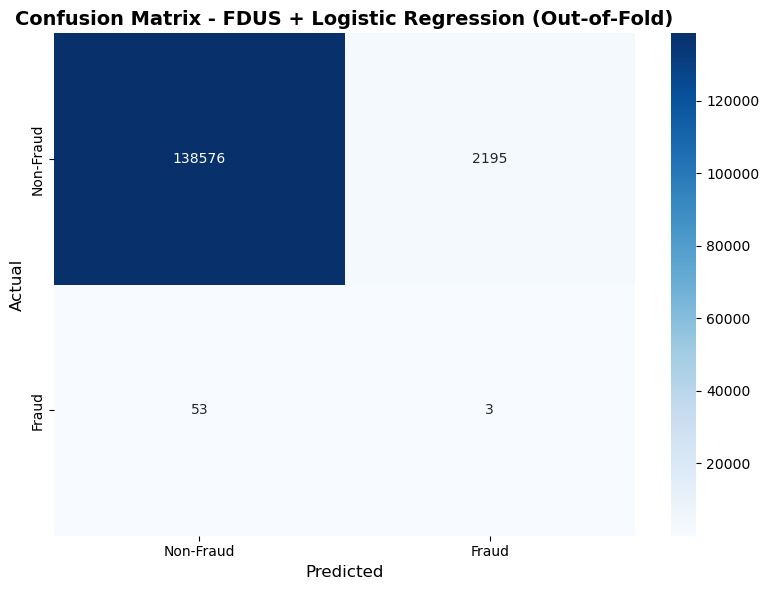


Detailed Breakdown:
  True Negatives: 138,576
  False Positives: 2,195
  False Negatives: 53
  True Positives: 3

  False Positive Rate: 0.0156
  False Negative Rate: 0.9464
  True Positive Rate (Recall): 0.0536


In [10]:
# Build the confusion matrix from out-of-fold predictions
cm = confusion_matrix(oof_labels, oof_preds)

# Display the confusion matrix as a table
print("Confusion Matrix (Out-of-Fold Predictions):")
cm_df = pd.DataFrame(
    cm,
    columns=['Predicted Non-Fraud', 'Predicted Fraud'],
    index=['Actual Non-Fraud', 'Actual Fraud']
)
print(cm_df)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)
plt.title('Confusion Matrix - FDUS + Logistic Regression (Out-of-Fold)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Unpack the confusion matrix
tn, fp, fn, tp = cm.ravel()

# Display detailed error rates
print("\nDetailed Breakdown:")
print(f"  True Negatives: {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives: {tp:,}")
print(f"\n  False Positive Rate: {fp / max(fp + tn, 1):.4f}")
print(f"  False Negative Rate: {fn / max(fn + tp, 1):.4f}")
print(f"  True Positive Rate (Recall): {tp / max(tp + fn, 1):.4f}")

# Precision-Recall Curves
Plot the out-of-fold precision-recall curve and per-fold curves to assess stability.

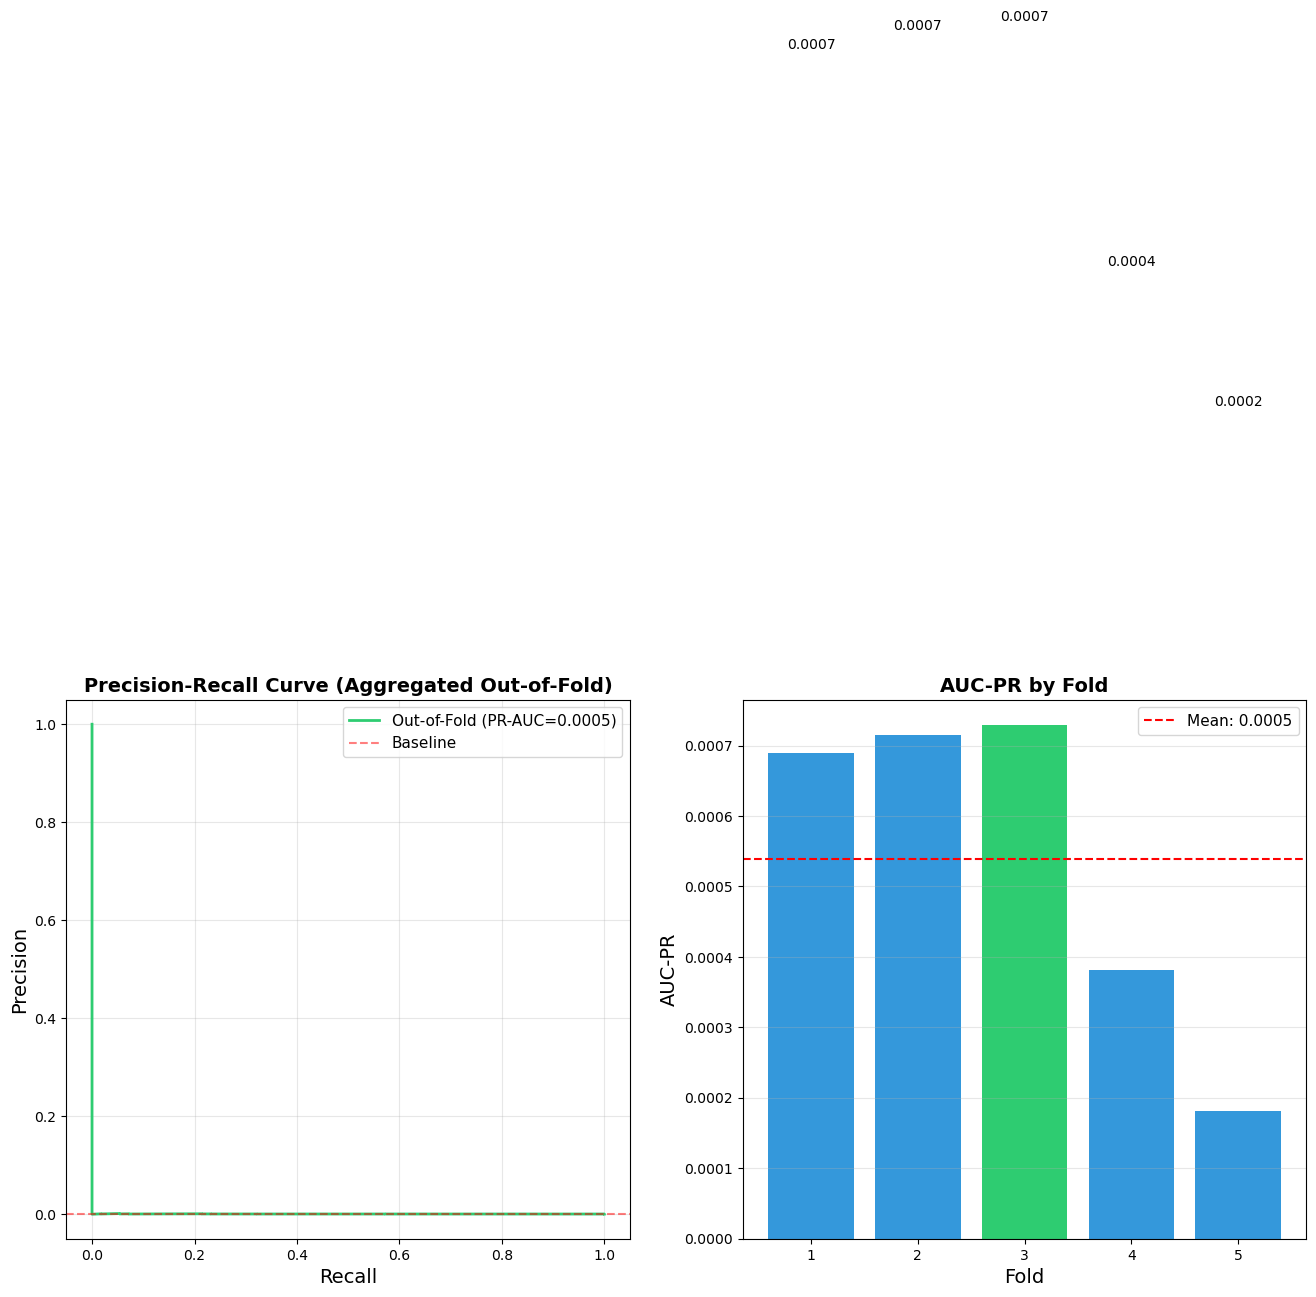

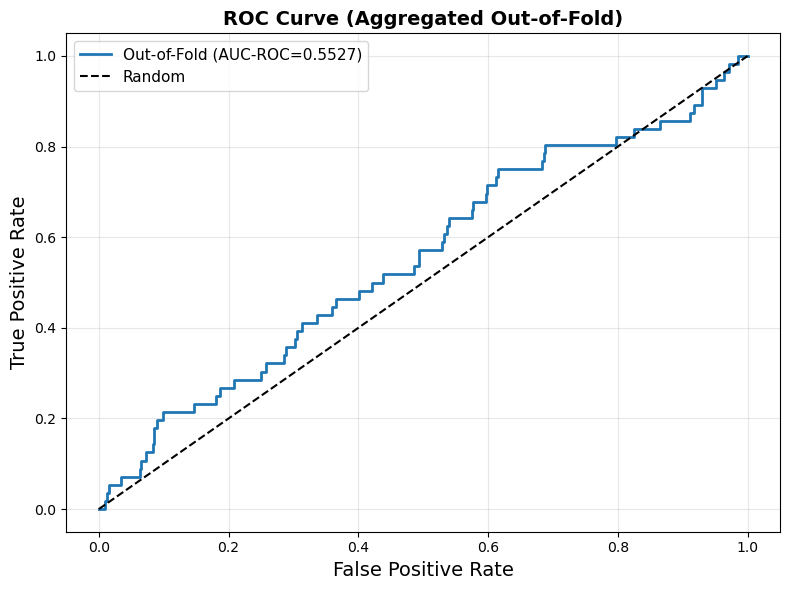

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Aggregated out-of-fold PR curve
precision_curve, recall_curve, _ = precision_recall_curve(oof_labels, oof_probas)
axes[0].plot(recall_curve, precision_curve, linewidth=2, color='#2ecc71',
             label=f'Out-of-Fold (PR-AUC={oof_metrics["pr_auc"]:.4f})')
axes[0].set_xlabel('Recall', fontsize=14)
axes[0].set_ylabel('Precision', fontsize=14)
axes[0].set_title('Precision-Recall Curve (Aggregated Out-of-Fold)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=minority_count / len(y), color='red', linestyle='--', alpha=0.5, label='Baseline')
axes[0].legend(loc='best', fontsize=11)

# Plot 2: Per-fold AUC-PR bar chart
fold_nums = cv_results_df['fold'].values
fold_auc_prs = cv_results_df['auc_pr'].values
colors_bar = ['#2ecc71' if v == fold_auc_prs.max() else '#3498db' for v in fold_auc_prs]

axes[1].bar(fold_nums, fold_auc_prs, color=colors_bar)
axes[1].axhline(y=cv_results_df['auc_pr'].mean(), color='red', linestyle='--',
                label=f'Mean: {cv_results_df["auc_pr"].mean():.4f}')
axes[1].set_xlabel('Fold', fontsize=14)
axes[1].set_ylabel('AUC-PR', fontsize=14)
axes[1].set_title('AUC-PR by Fold', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(fold_auc_prs):
    axes[1].text(fold_nums[i], v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Also plot ROC curve
fpr, tpr, _ = roc_curve(oof_labels, oof_probas)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Out-of-Fold (AUC-ROC={oof_metrics["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve (Aggregated Out-of-Fold)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Classification Report
Review the out-of-fold classification report using the selected threshold.

In [12]:
print("Classification Report: FDUS + Logistic Regression (Out-of-Fold)")
print(classification_report(oof_labels, oof_preds,
                             target_names=['Non-Fraud', 'Fraud'], zero_division=0))

Classification Report: FDUS + Logistic Regression (Out-of-Fold)
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.98      0.99    140771
       Fraud       0.00      0.05      0.00        56

    accuracy                           0.98    140827
   macro avg       0.50      0.52      0.50    140827
weighted avg       1.00      0.98      0.99    140827



# Feature Importance Analysis
Review the most important feature coefficients from the final tuned logistic regression model.

Top 20 Most Important Features (FDUS + Logistic Regression):
                                 feature  coefficient  abs_coefficient
                   bene_cc_ph_ckd_v2_pct      -0.3982           0.3982
                      bene_race_othr_cnt      -0.3925           0.3925
                  bene_cc_ph_copd_v2_pct       0.3162           0.3162
           active_medicaid_provider_flag      -0.3157           0.3157
          drug_suplr_mdcr_stdzd_pymt_amt      -0.2848           0.2848
             tot_suplr_nonrntl_hcpcs_cds       0.2838           0.2838
              tot_suplr_srvcs_max_zscore      -0.2625           0.2625
            total_payment_pctile_by_type      -0.2122           0.2122
      form_count_cash_or_cash_equivalent       0.2060           0.2060
                           hi_risk_hcpcs       0.1812           0.1812
                       bene_race_api_cnt      -0.1715           0.1715
                      non-covered_device      -0.1693           0.1693
                

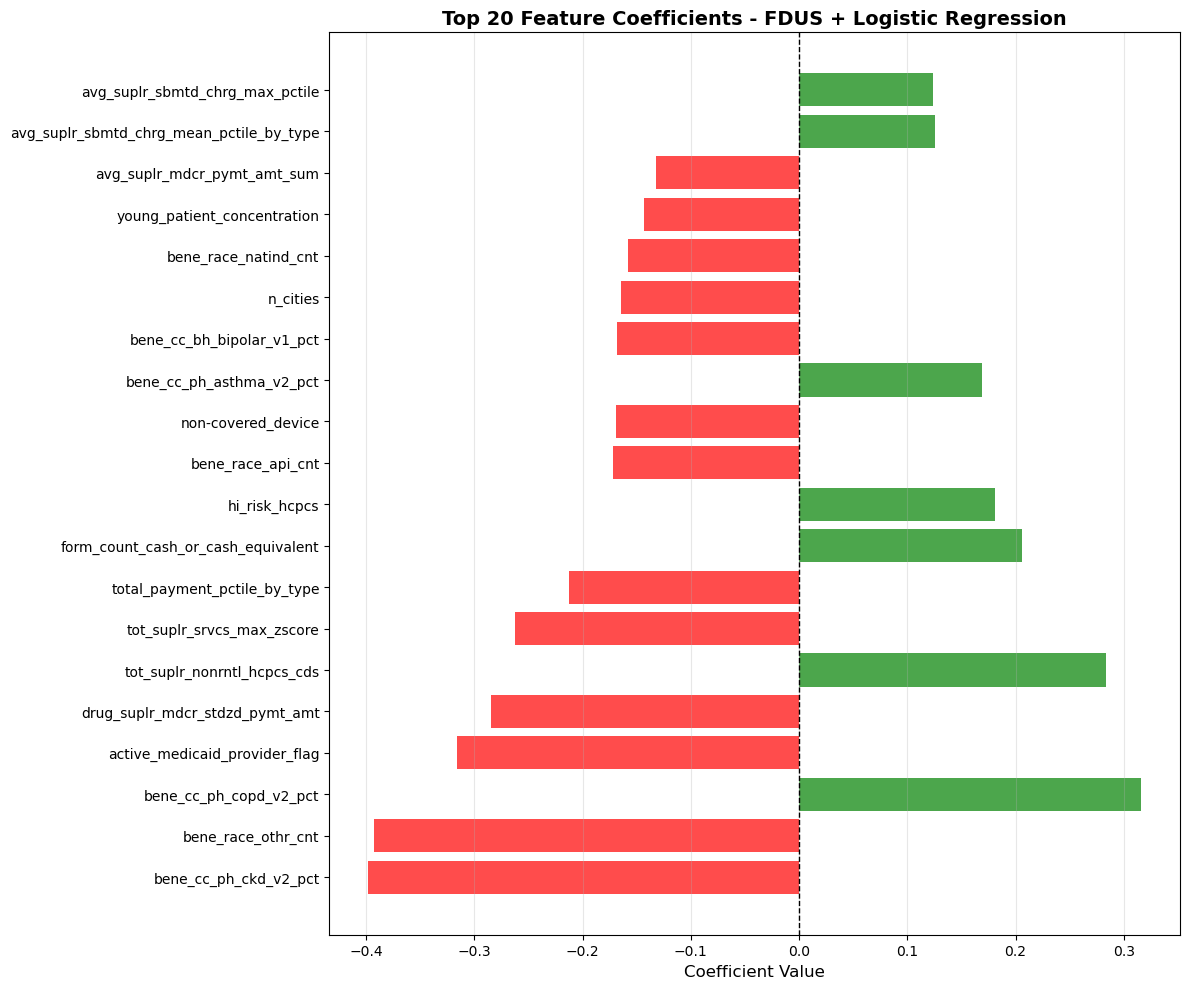


Coefficient Summary:
  Non-zero coefficients: 46 / 106
  Positive coefficients (fraud indicators): 13
  Negative coefficients (non-fraud indicators): 33


In [13]:
# Extract the logistic regression coefficients from the final model
coefficients = final_model.coef_[0]

# Build the feature importance table
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

# Display the top features
print("Top 20 Most Important Features (FDUS + Logistic Regression):")
print(feature_importance.head(20).to_string(index=False))

# Plot the top features
plt.figure(figsize=(12, 10))
top_features = feature_importance.head(20)
colors_feat = ['red' if value < 0 else 'green' for value in top_features['coefficient']]

plt.barh(range(len(top_features)), top_features['coefficient'], color=colors_feat, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 20 Feature Coefficients - FDUS + Logistic Regression', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Display coefficient summary statistics
print(f"\nCoefficient Summary:")
print(f"  Non-zero coefficients: {(np.abs(coefficients) > 1e-10).sum()} / {len(coefficients)}")
print(f"  Positive coefficients (fraud indicators): {(coefficients > 1e-10).sum()}")
print(f"  Negative coefficients (non-fraud indicators): {(coefficients < -1e-10).sum()}")

# NPI-Level Fraud Risk Probabilities
Generate a fraud risk probability for every NPI using the final model. Each NPI gets the maximum fraud probability across all its records (conservative approach for fraud detection).

NPI-Level Fraud Risk Summary:
  Total NPIs scored: 63,117
  NPIs with actual fraud: 23

Risk Tier Distribution:
risk_tier
Low           896
Medium       4776
High        24681
Critical    32764
Name: count, dtype: int64

Top 20 Highest Risk NPIs:
       npi  max_fraud_probability  mean_fraud_probability  n_records  n_flagged  actual_fraud risk_tier
1104879824                 0.9995                  0.6363          3          1             0  Critical
1316904048                 0.9964                  0.9964          1          1             0  Critical
1063895746                 0.9921                  0.9727          3          1             0  Critical
1912938234                 0.9900                  0.8875          3          1             0  Critical
1053318147                 0.9889                  0.9858          3          2             0  Critical
1548375629                 0.9877                  0.9798          3          1             0  Critical
1174520258               

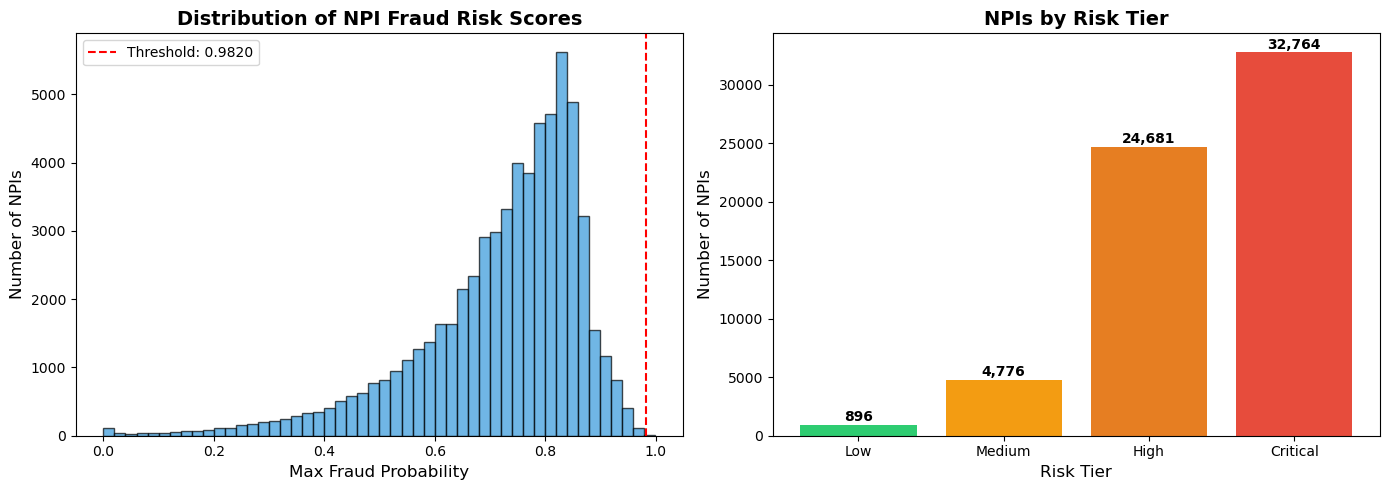

In [14]:
# Score every record in the full dataset with the final model
df_clean['fraud_probability'] = final_model.predict_proba(X_scaled)[:, 1]
df_clean['fraud_prediction'] = (df_clean['fraud_probability'] >= best_threshold).astype(int)

# Aggregate to NPI level: take the max probability per NPI (most suspicious record)
npi_risk = df_clean.groupby(npi_col).agg(
    max_fraud_probability=('fraud_probability', 'max'),
    mean_fraud_probability=('fraud_probability', 'mean'),
    n_records=('fraud_probability', 'count'),
    n_flagged=('fraud_prediction', 'sum'),
    actual_fraud=('target', 'max')
).reset_index()

# Sort by risk
npi_risk = npi_risk.sort_values('max_fraud_probability', ascending=False).reset_index(drop=True)

# Add risk tier
npi_risk['risk_tier'] = pd.cut(
    npi_risk['max_fraud_probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical'],
    include_lowest=True
)

print(f"NPI-Level Fraud Risk Summary:")
print(f"  Total NPIs scored: {len(npi_risk):,}")
print(f"  NPIs with actual fraud: {npi_risk['actual_fraud'].sum()}")
print(f"\nRisk Tier Distribution:")
print(npi_risk['risk_tier'].value_counts().sort_index())

print(f"\nTop 20 Highest Risk NPIs:")
print(npi_risk.head(20).to_string(index=False))

# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(npi_risk['max_fraud_probability'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Max Fraud Probability', fontsize=12)
axes[0].set_ylabel('Number of NPIs', fontsize=12)
axes[0].set_title('Distribution of NPI Fraud Risk Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=best_threshold, color='red', linestyle='--', label=f'Threshold: {best_threshold:.4f}')
axes[0].legend()

# Risk tiers
tier_counts = npi_risk['risk_tier'].value_counts().sort_index()
tier_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[1].bar(tier_counts.index.astype(str), tier_counts.values, color=tier_colors[:len(tier_counts)])
axes[1].set_xlabel('Risk Tier', fontsize=12)
axes[1].set_ylabel('Number of NPIs', fontsize=12)
axes[1].set_title('NPIs by Risk Tier', fontsize=14, fontweight='bold')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + max(tier_counts.values)*0.01, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Save Best Model and Results
Save the final tuned logistic regression model, the NPI risk scores, and all supporting metadata.

In [15]:
#################################################################
# BEST MODEL
################################################################
# Save the final model and scaler
model_bundle = {
    'model': final_model,
    'scaler': final_scaler,
    'feature_cols': feature_cols,
    'decision_threshold': best_threshold,
    'best_params': most_common_params,
    'fdus_config': {
        'ratio': fdus_ratio,
        'alpha': fdus_alpha,
        'n_clusters': fdus_n_clusters
    }
}
joblib.dump(model_bundle, 'best_logreg_fdus.pkl')
print("Model bundle saved as 'best_logreg_fdus.pkl'")

# Save model metadata
model_metadata = {
    'decision_threshold': best_threshold,
    'target_column': target_col,
    'feature_cols': feature_cols,
    'best_params': most_common_params,
    'cv_results': cv_results_df.to_dict(),
    'oof_metrics': oof_metrics,
    'full_data_metrics': full_metrics
}
joblib.dump(model_metadata, 'best_logreg_fdus_metadata.pkl')
print("Model metadata saved as 'best_logreg_fdus_metadata.pkl'")

# Save the NPI risk scores
npi_risk.to_csv('npi_fraud_risk_scores.csv', index=False)
print(f"NPI risk scores saved as 'npi_fraud_risk_scores.csv' ({len(npi_risk):,} NPIs)")

# Save the performance summary
performance_summary = pd.DataFrame([
    {
        'Dataset': 'Cross-Validation (mean)',
        'PR-AUC': cv_results_df['auc_pr'].mean(),
        'PR-AUC_std': cv_results_df['auc_pr'].std(),
        'ROC-AUC': cv_results_df['auc_roc'].mean(),
        'ROC-AUC_std': cv_results_df['auc_roc'].std()
    },
    {
        'Dataset': 'Out-of-Fold',
        'PR-AUC': oof_metrics['pr_auc'],
        'PR-AUC_std': np.nan,
        'ROC-AUC': oof_metrics['roc_auc'],
        'ROC-AUC_std': np.nan
    },
    {
        'Dataset': 'Full Data (refit)',
        'PR-AUC': full_metrics['pr_auc'],
        'PR-AUC_std': np.nan,
        'ROC-AUC': full_metrics['roc_auc'],
        'ROC-AUC_std': np.nan
    }
])
performance_summary.to_csv('model_performance_summary.csv', index=False)
print("Performance summary saved as 'model_performance_summary.csv'")

# Save feature importance
feature_importance.to_csv('feature_importance_coefficients.csv', index=False)
print("Feature coefficients saved as 'feature_importance_coefficients.csv'")

Model bundle saved as 'best_logreg_fdus.pkl'
Model metadata saved as 'best_logreg_fdus_metadata.pkl'
NPI risk scores saved as 'npi_fraud_risk_scores.csv' (63,117 NPIs)
Performance summary saved as 'model_performance_summary.csv'
Feature coefficients saved as 'feature_importance_coefficients.csv'


# Final Summary
Summarize the final model configuration and performance.

In [16]:
###########################################
# FINAL MODEL RESULTS
###############################################
print("FINAL MODEL SUMMARY")
print("-" * 80)

print(f"\nMethod: FDUS 1:{int(fdus_ratio)} + Logistic Regression")
print(f"Cross-Validation: {n_cv_folds}-Fold Stratified Group K-Fold (grouped by NPI)")
print(f"Gold Metric: AUC-PR (average_precision)")

print(f"\nHyperparameters:")
for param, value in most_common_params.items():
    print(f"  {param}: {value}")

print(f"\nPerformance:")
print(f"  Mean CV AUC-PR:  {cv_results_df['auc_pr'].mean():.4f} (+/- {cv_results_df['auc_pr'].std():.4f})")
print(f"  Mean CV AUC-ROC: {cv_results_df['auc_roc'].mean():.4f} (+/- {cv_results_df['auc_roc'].std():.4f})")
print(f"  Out-of-Fold AUC-PR:  {oof_metrics['pr_auc']:.4f}")
print(f"  Out-of-Fold Recall:  {oof_metrics['recall']:.4f}")

print(f"\nThreshold: {best_threshold:.4f}")

print(f"\nNPI Risk Scoring:")
print(f"  Total NPIs scored: {len(npi_risk):,}")
print(f"  NPIs flagged (above threshold): {(npi_risk['max_fraud_probability'] >= best_threshold).sum()}")

print(f"\nSaved Artifacts:")
print(f"  - best_logreg_fdus.pkl (model + scaler + config)")
print(f"  - best_logreg_fdus_metadata.pkl (metadata)")
print(f"  - npi_fraud_risk_scores.csv (NPI-level risk)")
print(f"  - model_performance_summary.csv")
print(f"  - feature_importance_coefficients.csv")

FINAL MODEL SUMMARY
--------------------------------------------------------------------------------

Method: FDUS 1:5 + Logistic Regression
Cross-Validation: 5-Fold Stratified Group K-Fold (grouped by NPI)
Gold Metric: AUC-PR (average_precision)

Hyperparameters:
  C: 0.1
  class_weight: {0: 1, 1: 10}
  penalty: l1
  solver: saga

Performance:
  Mean CV AUC-PR:  0.0005 (+/- 0.0002)
  Mean CV AUC-ROC: 0.5253 (+/- 0.0476)
  Out-of-Fold AUC-PR:  0.0005
  Out-of-Fold Recall:  0.0536

Threshold: 0.9820

NPI Risk Scoring:
  Total NPIs scored: 63,117
  NPIs flagged (above threshold): 12

Saved Artifacts:
  - best_logreg_fdus.pkl (model + scaler + config)
  - best_logreg_fdus_metadata.pkl (metadata)
  - npi_fraud_risk_scores.csv (NPI-level risk)
  - model_performance_summary.csv
  - feature_importance_coefficients.csv


# Save your Notebook, then `File > Close and Halt`